# 05a — PyCAP Parameter Perturbation for Selected Wells

**Purpose:** Focus the PyCAP perturbation analysis on a smaller set of decision-relevant wells.

This notebook builds from:

```text
04_pycap_parameter_perturbation.ipynb
```

The previous notebook showed that simple ±10% parameter perturbations were useful at the whole-model level. This notebook zooms in on selected wells so we can answer:

1. Which wells are most sensitive to `T`?
2. Which wells are most sensitive to `S`?
3. Do selected high-impact wells stay high-impact under stronger perturbations?
4. What happens if pumping `Q` changes only for selected wells?
5. Which selected wells are close to the `DP = 0.20` threshold?

## Scenarios in this notebook

This notebook uses a wider deterministic range than notebook `04`:

```text
T factors:          0.75, 0.90, 1.00, 1.10, 1.25
S factors:          0.75, 0.90, 1.00, 1.10, 1.25
Selected Q factors: 0.50, 0.75, 1.00, 1.25, 1.50
```

For the `Q_selected` cases, only the selected wells have their pumping rates changed. Other wells remain at baseline pumping.


## 1. Imports and project-root setup

In [1]:
from pathlib import Path
import os
import sys
import shutil
from copy import deepcopy
from datetime import datetime

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

def find_project_root(start=None):
    """Find the repository root by looking for common project marker files."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / ".git").exists() and (candidate / "environment.yml").exists():
            return candidate

    for candidate in candidates:
        if (candidate / "models").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Try opening Jupyter from the Modeling-Uncertainties repo root."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd()}")
print(f"Python executable: {sys.executable}")


Project root: /workspaces/Modeling-Uncertainties
Current working directory: /workspaces/Modeling-Uncertainties
Python executable: /opt/conda/envs/gw_uncertainty/bin/python


## 2. Define project paths

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
PYCAP_RESULTS_DIR = RESULTS_DIR / "pycap_runs"

LPR_PYCAP_RAW_DIR = DATA_DIR / "raw" / "lpr_pycap"
LPR_PYCAP_BASE_DIR = LPR_PYCAP_RAW_DIR / "pycap_base"
LPR_PYCAP_BASE_OUTPUT_DIR = LPR_PYCAP_BASE_DIR / "output"

PYCAP_RUN_NAME = "LPR_Redux"
PYCAP_YAML_NAME = f"{PYCAP_RUN_NAME}.yml"
PYCAP_YAML_PATH = LPR_PYCAP_BASE_DIR / PYCAP_YAML_NAME

SELECTED_WELLS_DIR = PYCAP_RESULTS_DIR / "selected_wells_perturbation"
SCENARIOS_DIR = SELECTED_WELLS_DIR / "scenarios"
TABLES_DIR = SELECTED_WELLS_DIR / "tables"
FIGURES_DIR = SELECTED_WELLS_DIR / "figures"

for folder in [SELECTED_WELLS_DIR, SCENARIOS_DIR, TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Baseline YAML:      {PYCAP_YAML_PATH.relative_to(PROJECT_ROOT)}")
print(f"Selected wells dir: {SELECTED_WELLS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Scenario run dir:   {SCENARIOS_DIR.relative_to(PROJECT_ROOT)}")


Baseline YAML:      data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
Selected wells dir: results/pycap_runs/selected_wells_perturbation
Scenario run dir:   results/pycap_runs/selected_wells_perturbation/scenarios


## 3. Import PyCAP

In [3]:
try:
    import pycap
    from pycap.analysis_project import Project

    print("PyCAP imported successfully.")
    print(f"pycap module: {pycap}")
    print(f"Project class: {Project}")

except Exception as err:
    print("PyCAP import failed.")
    print(type(err).__name__)
    print(err)
    raise


PyCAP imported successfully.
pycap module: <module 'pycap' from '/opt/conda/envs/gw_uncertainty/lib/python3.11/site-packages/pycap/__init__.py'>
Project class: <class 'pycap.analysis_project.Project'>


## 4. Load baseline YAML and define helper functions

In [4]:
with open(PYCAP_YAML_PATH, "r") as f:
    baseline_config = yaml.safe_load(f)

if not isinstance(baseline_config, dict):
    raise TypeError(f"Expected baseline YAML to load as a dictionary, got {type(baseline_config)}")

GPM_TO_CFS = 1 / 7.48052 / 60

def is_likely_well_entry(key, value):
    """Identify likely well entries from the PyCAP YAML."""
    if not isinstance(value, dict):
        return False

    key_text = str(key).lower()
    has_q = "Q" in value or "q" in value
    has_loc = isinstance(value.get("loc"), dict)
    key_says_well = "well" in key_text

    return key_says_well and (has_q or has_loc)


def build_well_inventory(config):
    """Build a simple well table from a PyCAP YAML dictionary."""
    rows = []

    for key, value in config.items():
        if not is_likely_well_entry(key, value):
            continue

        loc = value.get("loc", {})
        q_gpm = value.get("Q", value.get("q", np.nan))
        q_cfs = q_gpm * GPM_TO_CFS if pd.notna(q_gpm) else np.nan

        rows.append(
            {
                "well_key": key,
                "name": value.get("name", key),
                "Q_gpm": q_gpm,
                "Q_cfs": q_cfs,
                "x": loc.get("x", np.nan) if isinstance(loc, dict) else np.nan,
                "y": loc.get("y", np.nan) if isinstance(loc, dict) else np.nan,
            }
        )

    return pd.DataFrame(rows)


def write_yaml(config, yaml_path):
    """Write a PyCAP YAML dictionary to disk."""
    yaml_path.parent.mkdir(parents=True, exist_ok=True)
    with open(yaml_path, "w") as f:
        yaml.safe_dump(config, f, sort_keys=False)


def run_pycap_project(run_dir, yaml_name):
    """Run PyCAP in a scenario folder and return timing information."""
    run_dir = Path(run_dir)
    yaml_path = run_dir / yaml_name

    start_time = datetime.now()

    old_cwd = Path.cwd()
    os.chdir(run_dir)

    try:
        ap = Project(yaml_path)
        ap.report_responses()
        ap.write_responses_csv()
    finally:
        os.chdir(old_cwd)

    end_time = datetime.now()
    elapsed = end_time - start_time

    return {
        "start_time": start_time,
        "end_time": end_time,
        "elapsed": elapsed,
    }


def get_output_paths(run_dir):
    """Return expected PyCAP output paths for a scenario run folder."""
    output_dir = Path(run_dir) / "output"
    return {
        "report_txt": output_dir / f"{PYCAP_RUN_NAME}.report.txt",
        "table_report": output_dir / f"{PYCAP_RUN_NAME}.table_report.csv",
        "all_ts": output_dir / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
        "base_stream_depletion": output_dir / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
    }


def compute_depletion_potential(config, base_stream_depletion_path):
    """Compute depletion potential from a YAML dictionary and a base stream depletion output table."""
    wells_df = build_well_inventory(config)
    base_stream_depletion = pd.read_csv(base_stream_depletion_path, index_col=0)

    if "LPR" not in base_stream_depletion.columns:
        raise KeyError(
            f"Expected an 'LPR' column in {base_stream_depletion_path.name}. "
            f"Available columns: {list(base_stream_depletion.columns)}"
        )

    depletion_df = base_stream_depletion[["LPR"]].rename(columns={"LPR": "DEPL_cfs"})

    dp_df = wells_df.merge(
        depletion_df,
        left_on="name",
        right_index=True,
        how="left",
    )

    dp_df["Depletion_Potential"] = dp_df["DEPL_cfs"] / dp_df["Q_cfs"]

    return dp_df


def apply_selected_well_perturbation(config, parameter, factor, selected_well_keys=None):
    """Return a perturbed copy of the baseline PyCAP YAML dictionary."""
    config_new = deepcopy(config)

    if parameter == "baseline":
        return config_new

    if parameter in ["T", "S"]:
        props = config_new.get("project_properties", {})
        if parameter not in props:
            raise KeyError(f"Could not find project_properties['{parameter}'] in the YAML.")
        props[parameter] = props[parameter] * factor
        return config_new

    if parameter == "Q_selected":
        if selected_well_keys is None:
            raise ValueError("selected_well_keys must be provided for Q_selected perturbations.")

        n_changed = 0

        for key, value in config_new.items():
            if key not in selected_well_keys:
                continue
            if not is_likely_well_entry(key, value):
                continue

            if "Q" in value:
                value["Q"] = value["Q"] * factor
                n_changed += 1
            elif "q" in value:
                value["q"] = value["q"] * factor
                n_changed += 1

        if n_changed == 0:
            raise ValueError("No selected well pumping values were changed.")

        return config_new

    raise ValueError(f"Unknown parameter: {parameter}")


baseline_wells_df = build_well_inventory(baseline_config)

print(f"Loaded baseline YAML with {len(baseline_config)} top-level keys.")
print(f"Number of wells: {len(baseline_wells_df)}")
print(f"Baseline T: {baseline_config['project_properties'].get('T')}")
print(f"Baseline S: {baseline_config['project_properties'].get('S')}")


Loaded baseline YAML with 656 top-level keys.
Number of wells: 327
Baseline T: 1700.0
Baseline S: 0.12


## 5. Build baseline depletion-potential table

This uses the copied baseline PyCAP output table from:

```text
data/raw/lpr_pycap/pycap_base/output/
```


In [5]:
baseline_base_stream_path = (
    LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv"
)

baseline_dp = compute_depletion_potential(
    config=baseline_config,
    base_stream_depletion_path=baseline_base_stream_path,
)

baseline_dp = baseline_dp.sort_values("Depletion_Potential", ascending=False).reset_index(drop=True)

baseline_dp_path = TABLES_DIR / "baseline_depletion_potential_for_selection.csv"
baseline_dp.to_csv(baseline_dp_path, index=False)

print(f"Saved: {baseline_dp_path.relative_to(PROJECT_ROOT)}")
baseline_dp.head(15)


Saved: results/pycap_runs/selected_wells_perturbation/tables/baseline_depletion_potential_for_selection.csv


,well_key,name,Q_gpm,Q_cfs,x,y,DEPL_cfs,Depletion_Potential
0,well_23627,23627,276.5,0.616045,89.484380,44.475732,0.345167,0.560296
1,well_68529,68529,219.9,0.489939,89.484333,44.479917,0.274004,0.559261
2,well_23653,23653,263.6,0.587303,89.498433,44.465117,0.326483,0.555901
3,well_466,466,315.9,0.703828,89.493950,44.461175,0.383091,0.544296
4,well_23934,23934,370.6,0.825700,89.477778,44.486112,0.398148,0.482195
5,well_69049,69049,37.6,0.083773,89.475600,44.484350,0.039051,0.466146
6,well_467,467,296.9,0.661496,89.493973,44.458573,0.287480,0.434590
7,well_71109,71109,15.0,0.033420,89.496006,44.485207,0.014082,0.421362
8,well_24323,24323,206.4,0.459861,89.503300,44.464950,0.162236,0.352793
9,well_71110,71110,13.0,0.028964,89.498127,44.484075,0.009220,0.318309


## 6. Select focus wells

This notebook automatically selects a useful set of wells:

1. Top 5 wells by depletion potential.
2. Top 5 wells closest to the `DP = 0.20` threshold.
3. Top 5 wells by individual stream depletion.
4. A few lower-DP reference wells with relatively high pumping.

You can manually edit `MANUAL_WELL_KEYS` if you want to force specific wells into the analysis.


In [6]:
DP_THRESHOLD = 0.20

top_by_dp = (
    baseline_dp
    .sort_values("Depletion_Potential", ascending=False)
    .head(5)
    .assign(selection_reason="top_5_by_DP")
)

near_threshold = (
    baseline_dp
    .assign(abs_distance_to_threshold=lambda df: (df["Depletion_Potential"] - DP_THRESHOLD).abs())
    .sort_values("abs_distance_to_threshold")
    .head(5)
    .drop(columns=["abs_distance_to_threshold"])
    .assign(selection_reason="closest_to_DP_0_20")
)

top_by_depletion = (
    baseline_dp
    .sort_values("DEPL_cfs", ascending=False)
    .head(5)
    .assign(selection_reason="top_5_by_DEPL_cfs")
)

reference_low_dp = (
    baseline_dp
    .loc[baseline_dp["Depletion_Potential"] < 0.01]
    .sort_values("Q_gpm", ascending=False)
    .head(3)
    .assign(selection_reason="high_Q_low_DP_reference")
)

MANUAL_WELL_KEYS = [
    # Example: "well_23627",
]

manual_selection = baseline_dp[
    baseline_dp["well_key"].isin(MANUAL_WELL_KEYS)
].assign(selection_reason="manual_selection")

selected_wells = pd.concat(
    [
        top_by_dp,
        near_threshold,
        top_by_depletion,
        reference_low_dp,
        manual_selection,
    ],
    ignore_index=True,
)

selected_wells = (
    selected_wells
    .drop_duplicates(subset=["well_key"])
    .sort_values("Depletion_Potential", ascending=False)
    .reset_index(drop=True)
)

selected_well_keys = set(selected_wells["well_key"])

selected_wells_path = TABLES_DIR / "selected_wells.csv"
selected_wells.to_csv(selected_wells_path, index=False)

print(f"Number of selected wells: {len(selected_wells)}")
print(f"Saved: {selected_wells_path.relative_to(PROJECT_ROOT)}")

selected_wells[
    [
        "selection_reason",
        "well_key",
        "name",
        "Q_gpm",
        "DEPL_cfs",
        "Depletion_Potential",
        "x",
        "y",
    ]
]


Number of selected wells: 13
Saved: results/pycap_runs/selected_wells_perturbation/tables/selected_wells.csv


,selection_reason,well_key,name,Q_gpm,DEPL_cfs,Depletion_Potential,x,y
0,top_5_by_DP,well_23627,23627,276.5,3.451670e-01,5.602955e-01,89.484380,44.475732
1,top_5_by_DP,well_68529,68529,219.9,2.740037e-01,5.592607e-01,89.484333,44.479917
2,top_5_by_DP,well_23653,23653,263.6,3.264826e-01,5.559013e-01,89.498433,44.465117
3,top_5_by_DP,well_466,466,315.9,3.830911e-01,5.442964e-01,89.493950,44.461175
4,top_5_by_DP,well_23934,23934,370.6,3.981483e-01,4.821948e-01,89.477778,44.486112
5,closest_to_DP_0_20,well_23645,23645,158.8,7.893813e-02,2.231102e-01,89.515370,44.464845
6,closest_to_DP_0_20,well_23755,23755,794.6,3.921939e-01,2.215314e-01,89.484141,44.461779
7,closest_to_DP_0_20,well_23770,23770,239.9,1.132421e-01,2.118657e-01,89.503372,44.479507
8,closest_to_DP_0_20,well_68008,68008,1.6,7.443794e-04,2.088129e-01,89.522203,44.453628
9,closest_to_DP_0_20,well_23836,23836,568.6,2.110932e-01,1.666289e-01,89.490740,44.456269


## 7. Define selected-well perturbation scenarios

In [7]:
T_FACTORS = [0.75, 0.90, 1.00, 1.10, 1.25]
S_FACTORS = [0.75, 0.90, 1.00, 1.10, 1.25]
Q_SELECTED_FACTORS = [0.50, 0.75, 1.00, 1.25, 1.50]

scenario_specs = []

for factor in T_FACTORS:
    scenario_specs.append(
        {
            "scenario": f"T_{int(round(factor * 100)):03d}",
            "parameter": "T",
            "factor": factor,
            "description": f"Global transmissivity factor {factor}",
        }
    )

for factor in S_FACTORS:
    scenario_specs.append(
        {
            "scenario": f"S_{int(round(factor * 100)):03d}",
            "parameter": "S",
            "factor": factor,
            "description": f"Global storage factor {factor}",
        }
    )

for factor in Q_SELECTED_FACTORS:
    scenario_specs.append(
        {
            "scenario": f"Qsel_{int(round(factor * 100)):03d}",
            "parameter": "Q_selected",
            "factor": factor,
            "description": f"Selected-well pumping factor {factor}",
        }
    )

scenario_specs_df = pd.DataFrame(scenario_specs)
scenario_specs_path = TABLES_DIR / "selected_well_scenario_specs.csv"
scenario_specs_df.to_csv(scenario_specs_path, index=False)

print(f"Saved: {scenario_specs_path.relative_to(PROJECT_ROOT)}")
scenario_specs_df


Saved: results/pycap_runs/selected_wells_perturbation/tables/selected_well_scenario_specs.csv


,scenario,parameter,factor,description
0,T_075,T,0.75,Global transmissivity factor 0.75
1,T_090,T,0.90,Global transmissivity factor 0.9
2,T_100,T,1.00,Global transmissivity factor 1.0
3,T_110,T,1.10,Global transmissivity factor 1.1
4,T_125,T,1.25,Global transmissivity factor 1.25
5,S_075,S,0.75,Global storage factor 0.75
6,S_090,S,0.90,Global storage factor 0.9
7,S_100,S,1.00,Global storage factor 1.0
8,S_110,S,1.10,Global storage factor 1.1
9,S_125,S,1.25,Global storage factor 1.25


## 8. Run selected-well perturbation scenarios

Each scenario is a full PyCAP run, but the analysis below focuses on the selected wells.


In [8]:
OVERWRITE_SCENARIO_FOLDERS = True

scenario_dp_tables = {}
selected_scenario_rows = []
run_log_rows = []

for spec in scenario_specs:
    scenario = spec["scenario"]
    parameter = spec["parameter"]
    factor = spec["factor"]
    description = spec["description"]

    print("=" * 90)
    print(f"Scenario: {scenario}")
    print(f"Description: {description}")

    scenario_dir = SCENARIOS_DIR / scenario

    if scenario_dir.exists():
        if OVERWRITE_SCENARIO_FOLDERS:
            shutil.rmtree(scenario_dir)
        else:
            raise FileExistsError(
                f"Scenario folder already exists: {scenario_dir}. "
                "Set OVERWRITE_SCENARIO_FOLDERS = True to overwrite."
            )

    scenario_dir.mkdir(parents=True, exist_ok=True)

    scenario_config = apply_selected_well_perturbation(
        baseline_config,
        parameter=parameter,
        factor=factor,
        selected_well_keys=selected_well_keys,
    )

    scenario_yaml_path = scenario_dir / PYCAP_YAML_NAME
    write_yaml(scenario_config, scenario_yaml_path)

    timing = run_pycap_project(scenario_dir, PYCAP_YAML_NAME)
    print(f"Elapsed time: {timing['elapsed']}")

    output_paths = get_output_paths(scenario_dir)
    outputs_exist = {name: path.exists() for name, path in output_paths.items()}

    if not all(outputs_exist.values()):
        missing_outputs = [name for name, exists in outputs_exist.items() if not exists]
        raise FileNotFoundError(f"Scenario {scenario} is missing outputs: {missing_outputs}")

    dp_df = compute_depletion_potential(
        config=scenario_config,
        base_stream_depletion_path=output_paths["base_stream_depletion"],
    )

    dp_df.insert(0, "scenario", scenario)
    dp_df.insert(1, "parameter", parameter)
    dp_df.insert(2, "factor", factor)

    scenario_dp_tables[scenario] = dp_df

    selected_df = dp_df[dp_df["well_key"].isin(selected_well_keys)].copy()
    selected_scenario_rows.append(selected_df)

    run_log_rows.append(
        {
            "scenario": scenario,
            "description": description,
            "parameter": parameter,
            "factor": factor,
            "scenario_folder": str(scenario_dir.relative_to(PROJECT_ROOT)),
            "yaml_file": str(scenario_yaml_path.relative_to(PROJECT_ROOT)),
            "start_time": timing["start_time"].isoformat(timespec="seconds"),
            "end_time": timing["end_time"].isoformat(timespec="seconds"),
            "elapsed": str(timing["elapsed"]),
            "outputs_exist": all(outputs_exist.values()),
        }
    )

print("=" * 90)
print("All selected-well perturbation scenarios completed.")


Scenario: T_075
Description: Global transmissivity factor 0.75
Writing report to /workspaces/Modeling-Uncertainties/results/pycap_runs/selected_wells_perturbation/scenarios/T_075/LPR_Redux.yml.import_report



Successfully parsed /workspaces/Modeling-Uncertainties/results/pycap_runs/selected_wells_perturbation/scenarios/T_075/LPR_Redux.yml (high five!)
*************************
Summary follows:

WELLS:
326 existing wells:
	466
	467
	490
	509
	602
	603
	798
	807
	850
	862
	1013
	1302
	1323
	1486
	1584
	1589
	1643
	1683
	1860
	2544
	2750
	2886
	3473
	3949
	4171
	23610
	23611
	23618
	23620
	23627
	23629
	23630
	23631
	23635
	23637
	23638
	23639
	23645
	23646
	23648
	23653
	23695
	23697
	23698
	23699
	23700
	23709
	23710
	23715
	23716
	23720
	23721
	23722
	23723
	23726
	23727
	23728
	23729
	23751
	23752
	23753
	23754
	23755
	23756
	23757
	23758
	23770
	23776
	23778
	23781
	23790
	23791
	23794
	23795
	23798
	23800
	23807
	23816
	23818
	23820
	23823
	23836
	23837
	23846
	23847
	23848
	23851


## 9. Combine and save selected-well results

In [9]:
all_selected_results = pd.concat(selected_scenario_rows, ignore_index=True)
all_scenario_dp = pd.concat(scenario_dp_tables.values(), ignore_index=True)
run_log = pd.DataFrame(run_log_rows)

all_selected_results_path = TABLES_DIR / "all_selected_well_scenario_results.csv"
all_scenario_dp_path = TABLES_DIR / "all_scenario_depletion_potential.csv"
run_log_path = TABLES_DIR / "selected_well_run_log.csv"

all_selected_results.to_csv(all_selected_results_path, index=False)
all_scenario_dp.to_csv(all_scenario_dp_path, index=False)
run_log.to_csv(run_log_path, index=False)

print(f"Saved: {all_selected_results_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {all_scenario_dp_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {run_log_path.relative_to(PROJECT_ROOT)}")

all_selected_results.head()


Saved: results/pycap_runs/selected_wells_perturbation/tables/all_selected_well_scenario_results.csv
Saved: results/pycap_runs/selected_wells_perturbation/tables/all_scenario_depletion_potential.csv
Saved: results/pycap_runs/selected_wells_perturbation/tables/selected_well_run_log.csv


,scenario,parameter,factor,well_key,name,Q_gpm,Q_cfs,x,y,DEPL_cfs,Depletion_Potential
0,T_075,T,0.75,well_466,466,315.9,0.703828,89.493950,44.461175,0.357482,0.507911
1,T_075,T,0.75,well_23627,23627,276.5,0.616045,89.484380,44.475732,0.316249,0.513355
2,T_075,T,0.75,well_23645,23645,158.8,0.353808,89.515370,44.464845,0.067969,0.192108
3,T_075,T,0.75,well_23653,23653,263.6,0.587303,89.498433,44.465117,0.300720,0.512035
4,T_075,T,0.75,well_23755,23755,794.6,1.770376,89.484141,44.461779,0.338160,0.191010


## 10. Compare selected-well results to baseline

This table calculates change in stream depletion and depletion potential relative to the baseline selected-well values.


In [10]:
baseline_selected = baseline_dp[
    baseline_dp["well_key"].isin(selected_well_keys)
][
    ["well_key", "name", "Q_gpm", "Q_cfs", "DEPL_cfs", "Depletion_Potential"]
].rename(
    columns={
        "Q_gpm": "baseline_Q_gpm",
        "Q_cfs": "baseline_Q_cfs",
        "DEPL_cfs": "baseline_DEPL_cfs",
        "Depletion_Potential": "baseline_DP",
    }
)

selected_comparisons = all_selected_results.merge(
    baseline_selected,
    on=["well_key", "name"],
    how="left",
)

selected_comparisons["delta_DEPL_cfs"] = (
    selected_comparisons["DEPL_cfs"] - selected_comparisons["baseline_DEPL_cfs"]
)

selected_comparisons["pct_delta_DEPL"] = (
    100 * selected_comparisons["delta_DEPL_cfs"] / selected_comparisons["baseline_DEPL_cfs"]
)

selected_comparisons["delta_DP"] = (
    selected_comparisons["Depletion_Potential"] - selected_comparisons["baseline_DP"]
)

selected_comparisons["pct_delta_DP"] = (
    100 * selected_comparisons["delta_DP"] / selected_comparisons["baseline_DP"]
)

for col in ["pct_delta_DEPL", "pct_delta_DP"]:
    selected_comparisons[col] = selected_comparisons[col].replace([np.inf, -np.inf], np.nan)

selected_comparisons_path = TABLES_DIR / "selected_well_scenario_vs_baseline.csv"
selected_comparisons.to_csv(selected_comparisons_path, index=False)

print(f"Saved: {selected_comparisons_path.relative_to(PROJECT_ROOT)}")
selected_comparisons.head()


Saved: results/pycap_runs/selected_wells_perturbation/tables/selected_well_scenario_vs_baseline.csv


,scenario,parameter,factor,well_key,name,Q_gpm,Q_cfs,x,y,DEPL_cfs,Depletion_Potential,baseline_Q_gpm,baseline_Q_cfs,baseline_DEPL_cfs,baseline_DP,delta_DEPL_cfs,pct_delta_DEPL,delta_DP,pct_delta_DP
0,T_075,T,0.75,well_466,466,315.9,0.703828,89.493950,44.461175,0.357482,0.507911,315.9,0.703828,0.383091,0.544296,-0.025609,-6.684767,-0.036385,-6.684767
1,T_075,T,0.75,well_23627,23627,276.5,0.616045,89.484380,44.475732,0.316249,0.513355,276.5,0.616045,0.345167,0.560296,-0.028918,-8.377871,-0.046941,-8.377871
2,T_075,T,0.75,well_23645,23645,158.8,0.353808,89.515370,44.464845,0.067969,0.192108,158.8,0.353808,0.078938,0.223110,-0.010969,-13.895507,-0.031002,-13.895507
3,T_075,T,0.75,well_23653,23653,263.6,0.587303,89.498433,44.465117,0.300720,0.512035,263.6,0.587303,0.326483,0.555901,-0.025763,-7.890928,-0.043866,-7.890928
4,T_075,T,0.75,well_23755,23755,794.6,1.770376,89.484141,44.461779,0.338160,0.191010,794.6,1.770376,0.392194,0.221531,-0.054034,-13.777374,-0.030521,-13.777374


## 11. Sensitivity summary for selected wells

In [11]:
sensitivity_summary = (
    selected_comparisons
    .groupby(["well_key", "name", "parameter"], as_index=False)
    .agg(
        baseline_DP=("baseline_DP", "first"),
        baseline_DEPL_cfs=("baseline_DEPL_cfs", "first"),
        min_DP=("Depletion_Potential", "min"),
        max_DP=("Depletion_Potential", "max"),
        range_DP=("Depletion_Potential", lambda x: x.max() - x.min()),
        min_DEPL_cfs=("DEPL_cfs", "min"),
        max_DEPL_cfs=("DEPL_cfs", "max"),
        range_DEPL_cfs=("DEPL_cfs", lambda x: x.max() - x.min()),
        max_abs_delta_DP=("delta_DP", lambda x: x.abs().max()),
        max_abs_delta_DEPL_cfs=("delta_DEPL_cfs", lambda x: x.abs().max()),
    )
    .sort_values(["parameter", "max_abs_delta_DP"], ascending=[True, False])
)

sensitivity_summary_path = TABLES_DIR / "selected_well_sensitivity_summary.csv"
sensitivity_summary.to_csv(sensitivity_summary_path, index=False)

print(f"Saved: {sensitivity_summary_path.relative_to(PROJECT_ROOT)}")
sensitivity_summary


Saved: results/pycap_runs/selected_wells_perturbation/tables/selected_well_sensitivity_summary.csv


,well_key,name,parameter,baseline_DP,baseline_DEPL_cfs,min_DP,max_DP,range_DP,min_DEPL_cfs,max_DEPL_cfs,range_DEPL_cfs,max_abs_delta_DP,max_abs_delta_DEPL_cfs
33,well_68008,68008,Q_selected,2.088129e-01,7.443794e-04,2.088129e-01,2.088129e-01,2.245426e-14,3.721897e-04,1.116569e-03,7.443794e-04,2.245426e-14,3.721897e-04
24,well_23934,23934,Q_selected,4.821948e-01,3.981483e-01,4.821948e-01,4.821948e-01,4.440892e-16,1.990742e-01,5.972225e-01,3.981483e-01,4.440892e-16,1.990742e-01
36,well_68529,68529,Q_selected,5.592607e-01,2.740037e-01,5.592607e-01,5.592607e-01,6.661338e-16,1.370019e-01,4.110056e-01,2.740037e-01,4.440892e-16,1.370019e-01
3,well_23645,23645,Q_selected,2.231102e-01,7.893813e-02,2.231102e-01,2.231102e-01,3.885781e-16,3.946907e-02,1.184072e-01,7.893813e-02,3.885781e-16,3.946907e-02
12,well_23770,23770,Q_selected,2.118657e-01,1.132421e-01,2.118657e-01,2.118657e-01,2.498002e-16,5.662103e-02,1.698631e-01,1.132421e-01,2.498002e-16,5.662103e-02
6,well_23653,23653,Q_selected,5.559013e-01,3.264826e-01,5.559013e-01,5.559013e-01,3.330669e-16,1.632413e-01,4.897239e-01,3.264826e-01,2.220446e-16,1.632413e-01
9,well_23755,23755,Q_selected,2.215314e-01,3.921939e-01,2.215314e-01,2.215314e-01,1.665335e-16,1.960969e-01,5.882908e-01,3.921939e-01,1.665335e-16,1.960969e-01
15,well_23836,23836,Q_selected,1.666289e-01,2.110932e-01,1.666289e-01,1.666289e-01,1.387779e-16,1.055466e-01,3.166398e-01,2.110932e-01,1.387779e-16,1.055466e-01
27,well_23983,23983,Q_selected,1.558419e-04,2.799958e-04,1.558419e-04,1.558419e-04,5.938717e-17,1.399979e-04,4.199938e-04,2.799958e-04,3.713392e-17,1.399979e-04
18,well_23864,23864,Q_selected,5.641570e-04,1.425001e-03,5.641570e-04,5.641570e-04,1.084202e-19,7.125004e-04,2.137501e-03,1.425001e-03,1.084202e-19,7.125004e-04


## 12. Which selected wells cross the DP = 0.20 threshold?

In [12]:
threshold_crossing = selected_comparisons.copy()
threshold_crossing["baseline_above_0_20"] = threshold_crossing["baseline_DP"] >= 0.20
threshold_crossing["scenario_above_0_20"] = threshold_crossing["Depletion_Potential"] >= 0.20
threshold_crossing["crossed_threshold"] = (
    threshold_crossing["baseline_above_0_20"] != threshold_crossing["scenario_above_0_20"]
)

threshold_crossing_table = threshold_crossing[
    threshold_crossing["crossed_threshold"]
][
    [
        "scenario",
        "parameter",
        "factor",
        "well_key",
        "name",
        "baseline_DP",
        "Depletion_Potential",
        "baseline_above_0_20",
        "scenario_above_0_20",
    ]
].sort_values(["well_key", "parameter", "factor"])

threshold_crossing_path = TABLES_DIR / "selected_well_dp_020_threshold_crossings.csv"
threshold_crossing_table.to_csv(threshold_crossing_path, index=False)

print(f"Saved: {threshold_crossing_path.relative_to(PROJECT_ROOT)}")
threshold_crossing_table


Saved: results/pycap_runs/selected_wells_perturbation/tables/selected_well_dp_020_threshold_crossings.csv


,scenario,parameter,factor,well_key,name,baseline_DP,Depletion_Potential,baseline_above_0_20,scenario_above_0_20
119,S_125,S,1.25,well_23645,23645,0.223110,0.198677,True,False
2,T_075,T,0.75,well_23645,23645,0.223110,0.192108,True,False
121,S_125,S,1.25,well_23755,23755,0.221531,0.197410,True,False
4,T_075,T,0.75,well_23755,23755,0.221531,0.191010,True,False
122,S_125,S,1.25,well_23770,23770,0.211866,0.190994,True,False
5,T_075,T,0.75,well_23770,23770,0.211866,0.185342,True,False
115,S_110,S,1.10,well_68008,68008,0.208813,0.195672,True,False
128,S_125,S,1.25,well_68008,68008,0.208813,0.177963,True,False
11,T_075,T,0.75,well_68008,68008,0.208813,0.169026,True,False
24,T_090,T,0.90,well_68008,68008,0.208813,0.194282,True,False


## 13. Plot selected-well DP response to T

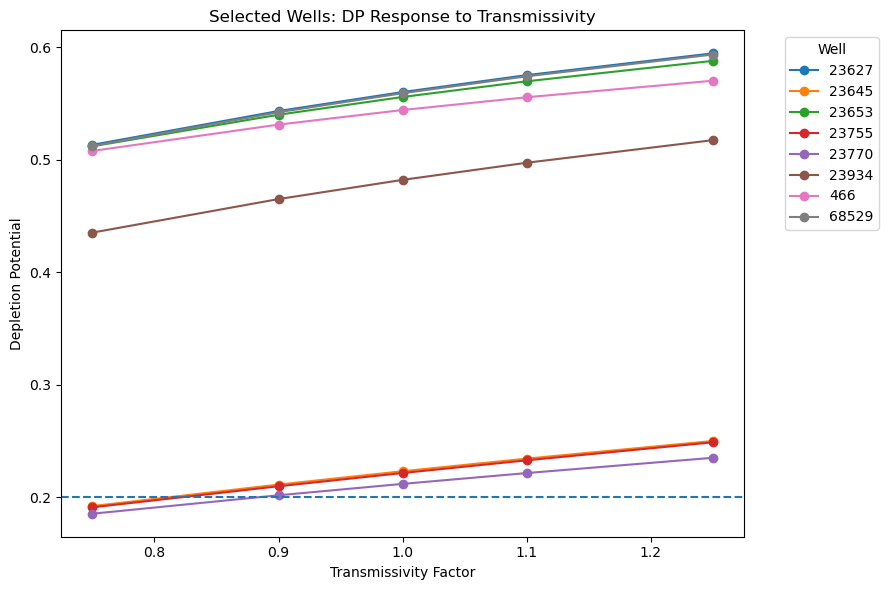

Saved: results/pycap_runs/selected_wells_perturbation/figures/selected_wells_dp_response_to_T.png


In [13]:
PLOT_TOP_N = min(8, len(selected_wells))
plot_wells = selected_wells.sort_values("Depletion_Potential", ascending=False).head(PLOT_TOP_N)["well_key"].tolist()

t_plot_df = selected_comparisons[
    (selected_comparisons["parameter"] == "T")
    & (selected_comparisons["well_key"].isin(plot_wells))
].copy()

plt.figure(figsize=(9, 6))

for well_key, group in t_plot_df.groupby("well_key"):
    group = group.sort_values("factor")
    well_name = group["name"].iloc[0]
    plt.plot(group["factor"], group["Depletion_Potential"], marker="o", label=str(well_name))

plt.axhline(0.20, linestyle="--")
plt.xlabel("Transmissivity Factor")
plt.ylabel("Depletion Potential")
plt.title("Selected Wells: DP Response to Transmissivity")
plt.legend(title="Well", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

fig_path = FIGURES_DIR / "selected_wells_dp_response_to_T.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 14. Plot selected-well DP response to S

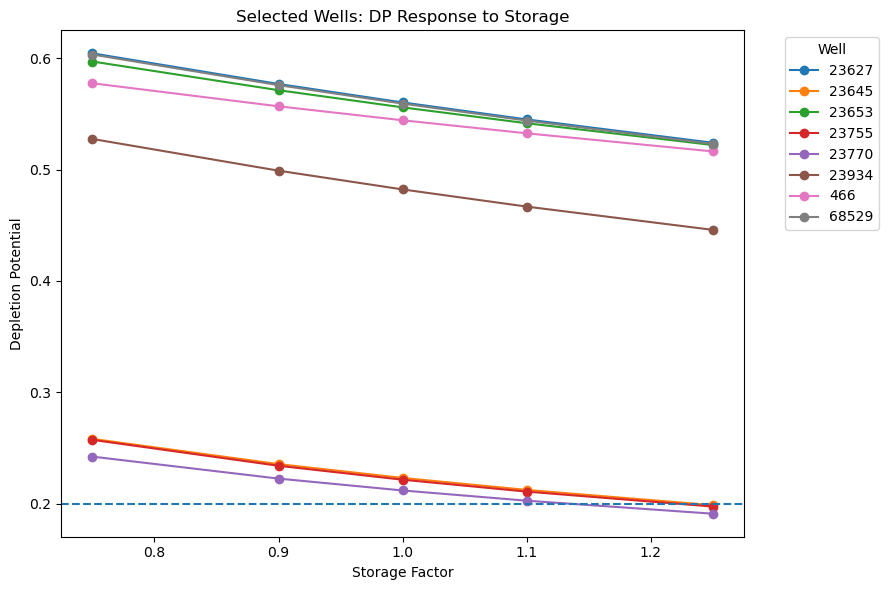

Saved: results/pycap_runs/selected_wells_perturbation/figures/selected_wells_dp_response_to_S.png


In [14]:
s_plot_df = selected_comparisons[
    (selected_comparisons["parameter"] == "S")
    & (selected_comparisons["well_key"].isin(plot_wells))
].copy()

plt.figure(figsize=(9, 6))

for well_key, group in s_plot_df.groupby("well_key"):
    group = group.sort_values("factor")
    well_name = group["name"].iloc[0]
    plt.plot(group["factor"], group["Depletion_Potential"], marker="o", label=str(well_name))

plt.axhline(0.20, linestyle="--")
plt.xlabel("Storage Factor")
plt.ylabel("Depletion Potential")
plt.title("Selected Wells: DP Response to Storage")
plt.legend(title="Well", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

fig_path = FIGURES_DIR / "selected_wells_dp_response_to_S.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 15. Plot selected-well depletion and DP response to selected-well Q

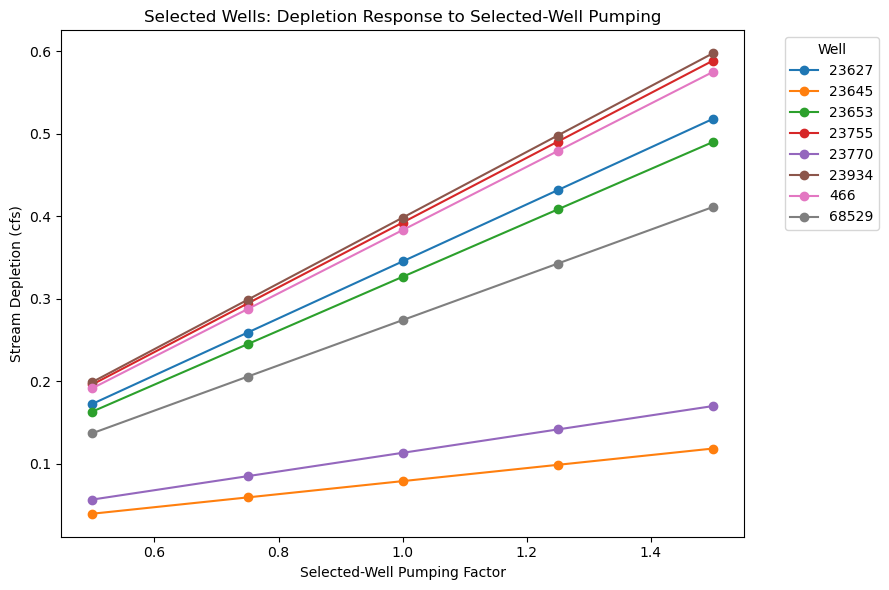

Saved: results/pycap_runs/selected_wells_perturbation/figures/selected_wells_depletion_response_to_Q_selected.png


In [15]:
q_plot_df = selected_comparisons[
    (selected_comparisons["parameter"] == "Q_selected")
    & (selected_comparisons["well_key"].isin(plot_wells))
].copy()

plt.figure(figsize=(9, 6))

for well_key, group in q_plot_df.groupby("well_key"):
    group = group.sort_values("factor")
    well_name = group["name"].iloc[0]
    plt.plot(group["factor"], group["DEPL_cfs"], marker="o", label=str(well_name))

plt.xlabel("Selected-Well Pumping Factor")
plt.ylabel("Stream Depletion (cfs)")
plt.title("Selected Wells: Depletion Response to Selected-Well Pumping")
plt.legend(title="Well", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

fig_path = FIGURES_DIR / "selected_wells_depletion_response_to_Q_selected.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


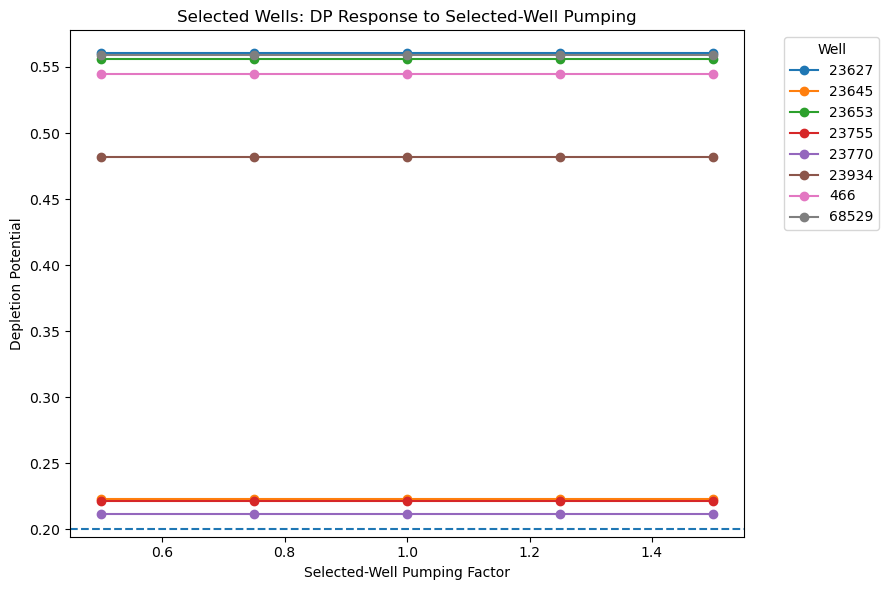

Saved: results/pycap_runs/selected_wells_perturbation/figures/selected_wells_dp_response_to_Q_selected.png


In [16]:
plt.figure(figsize=(9, 6))

for well_key, group in q_plot_df.groupby("well_key"):
    group = group.sort_values("factor")
    well_name = group["name"].iloc[0]
    plt.plot(group["factor"], group["Depletion_Potential"], marker="o", label=str(well_name))

plt.axhline(0.20, linestyle="--")
plt.xlabel("Selected-Well Pumping Factor")
plt.ylabel("Depletion Potential")
plt.title("Selected Wells: DP Response to Selected-Well Pumping")
plt.legend(title="Well", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

fig_path = FIGURES_DIR / "selected_wells_dp_response_to_Q_selected.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 16. First-pass interpretation table

In [17]:
interpretation_rows = []

for parameter in ["T", "S", "Q_selected"]:
    subset = sensitivity_summary[sensitivity_summary["parameter"] == parameter].copy()

    if subset.empty:
        continue

    most_sensitive = subset.sort_values("max_abs_delta_DP", ascending=False).iloc[0]

    if parameter == "Q_selected":
        note = (
            "Changing Q for selected wells changes depletion magnitude, but DP may remain nearly constant "
            "because DP is depletion divided by pumping."
        )
    elif parameter == "T":
        note = (
            "Changing T affects how strongly the analytical depletion signal reaches the stream over the "
            "evaluation period."
        )
    elif parameter == "S":
        note = (
            "Changing S affects the timing of the depletion response. Lower storage often increases "
            "depletion within a fixed time horizon."
        )
    else:
        note = "Review this parameter."

    interpretation_rows.append(
        {
            "parameter": parameter,
            "most_sensitive_well_key": most_sensitive["well_key"],
            "most_sensitive_well_name": most_sensitive["name"],
            "max_abs_delta_DP_for_that_well": most_sensitive["max_abs_delta_DP"],
            "note": note,
        }
    )

interpretation_table = pd.DataFrame(interpretation_rows)

interpretation_path = TABLES_DIR / "selected_well_first_pass_interpretation.csv"
interpretation_table.to_csv(interpretation_path, index=False)

print(f"Saved: {interpretation_path.relative_to(PROJECT_ROOT)}")
interpretation_table


Saved: results/pycap_runs/selected_wells_perturbation/tables/selected_well_first_pass_interpretation.csv


,parameter,most_sensitive_well_key,most_sensitive_well_name,max_abs_delta_DP_for_that_well,note
0,T,well_23627,23627,4.694084e-02,Changing T affects how strongly the analytical...
1,S,well_23934,23934,4.533111e-02,Changing S affects the timing of the depletion...
2,Q_selected,well_68008,68008,2.245426e-14,Changing Q for selected wells changes depletio...


## 17. Save notebook summary

In [18]:
notebook_summary = pd.DataFrame(
    [
        {"item": "project_root", "value": str(PROJECT_ROOT)},
        {"item": "baseline_yaml", "value": str(PYCAP_YAML_PATH.relative_to(PROJECT_ROOT))},
        {"item": "selected_wells_folder", "value": str(SELECTED_WELLS_DIR.relative_to(PROJECT_ROOT))},
        {"item": "number_of_selected_wells", "value": len(selected_wells)},
        {"item": "number_of_scenarios", "value": len(scenario_specs_df)},
        {"item": "baseline_T", "value": baseline_config["project_properties"].get("T")},
        {"item": "baseline_S", "value": baseline_config["project_properties"].get("S")},
        {"item": "dp_threshold_used", "value": DP_THRESHOLD},
        {"item": "threshold_crossing_count", "value": len(threshold_crossing_table)},
        {"item": "run_timestamp", "value": datetime.now().isoformat(timespec="seconds")},
    ]
)

notebook_summary_path = TABLES_DIR / "selected_well_notebook_summary.csv"
notebook_summary.to_csv(notebook_summary_path, index=False)

print(f"Saved: {notebook_summary_path.relative_to(PROJECT_ROOT)}")
notebook_summary


Saved: results/pycap_runs/selected_wells_perturbation/tables/selected_well_notebook_summary.csv


,item,value
0,project_root,/workspaces/Modeling-Uncertainties
1,baseline_yaml,data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
2,selected_wells_folder,results/pycap_runs/selected_wells_perturbation
3,number_of_selected_wells,13
4,number_of_scenarios,15
5,baseline_T,1700.0
6,baseline_S,0.12
7,dp_threshold_used,0.2
8,threshold_crossing_count,10
9,run_timestamp,2026-04-19T05:36:54


## 18. Final interpretation

This notebook helps you move from whole-model perturbations to **decision-relevant wells**.

Key things to look for after running this notebook:

1. Which selected wells have the largest absolute change in DP?
2. Which wells cross the `DP = 0.20` threshold?
3. Does `Q_selected` change depletion but leave DP nearly unchanged?
4. Are wells near the threshold more sensitive than the top-ranked wells?
5. Which plots are most useful for your independent-project report?

The companion notebook is:

```text
05b_pycap_monte_carlo_uncertainty.ipynb
```

That notebook will test many sampled combinations of `T`, `S`, and `Q` rather than changing one factor at a time.
